# Tutorial 8 – Equity Screening & Stock Selection Case
## FINM3422 – Professional Equity Research Workflow

**Estimated time:** ~2 hours (group-based)

---

### Scenario

You are part of a junior **equity research team** at an asset management firm.

Management has asked your team to:

> **Screen a universe of NASDAQ-listed technology companies and recommend ONE stock**
> for deeper fundamental analysis later in the course.

This notebook is intentionally structured like a **professional research notebook**,
following the modelling discipline discussed in **Lecture 6**.

You will work **collaboratively** using GitHub feature branches and pull requests.

## 1. Environment & Imports (≈5 minutes)

Professional modelling always begins by making the computing environment explicit.

Why this matters:
- Reproducibility across machines
- Clear collaboration in teams
- Fewer hidden bugs caused by implicit state

In this tutorial, we use **yfinance**, a free and stable Python library that provides
programmatic access to Yahoo Finance data.

No API key is required, which removes setup friction during tutorials.

In [1]:
# If needed (run once): pip install yfinance in console or use %pip install yfinance in your notebook

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

## What is the yfinance API?

`yfinance` is a Python wrapper around Yahoo Finance endpoints.
It allows analysts to retrieve:

- historical price data (daily, weekly, monthly)
- company metadata
- financial statements (income statement, balance sheet, cash flow)

It is:
- ✅ free
- ✅ fast to learn
- ✅ widely used for research prototyping and teaching

⚠️ Important:
`yfinance` is **not an institutional-grade data source** (e.g. Bloomberg or Refinitiv),
but it is perfectly suitable for **learning professional modelling workflows**.

## 2. Define the Investment Universe (≈5 minutes)

Equity research always begins with a clearly defined **investment universe**.

We restrict attention to a curated list of **large‑cap NASDAQ technology companies**.

Using a fixed universe ensures:
- Comparability across tutorial teams
- Stable API behaviour in class
- Focus on modelling rather than data hunting

In [2]:
tickers = [
    "AAPL",  # Apple
    "MSFT",  # Microsoft
    "NVDA",  # Nvidia
    "ADBE",  # Adobe
    "META",  # Meta Platforms
    "CRM",   # Salesforce
    "ORCL",  # Oracle
    "NOW",   # ServiceNow
    "INTU",  # Intuit
    "AMD"    # Advanced Micro Devices
]

## 3. Price Data Ingestion – API → DataFrame (≈15 minutes)

In professional workflows, analysts **do not manually download CSV files**.
Instead, data is pulled programmatically via APIs.

The main function used by yfinance is:

    yf.download()

### Key parameters you must understand

- `tickers`
  A single ticker (string) or multiple tickers (list)

- `interval`
  Controls **frequency** of observations  
  Examples:
  - `"1d"`  → daily data
  - `"1wk"` → weekly data
  - `"1mo"` → monthly data

- `period`
  Controls **how much history** is returned  
  Examples:
  - `"1y"`   → last year
  - `"5y"`   → last 5 years
  - `"max"`  → full available history

⚠️ **Critical rule**
> Never rely on API defaults. Always specify `period` explicitly.

## Why We Use Monthly Data in This Tutorial

In FINM3422:
- portfolio returns are monthly
- performance metrics are monthly
- Assignment 2 uses monthly frequency

Therefore, we deliberately request:
- `interval = "1mo"` → monthly observations
- `period = "max"`   → long historical window

This ensures:
- frequency is correct before computing returns
- enough observations exist for rolling metrics
- alignment with Lecture 6 modelling discipline

In [6]:
# TODO:
# Use yf.download to retrieve monthly adjusted prices
# - interval="1mo"
# - period="max"
# - auto_adjust=True
# Then:
# - keep adjusted close prices
# - ensure DatetimeIndex
# - sort index


prices = yf.download(
    tickers=tickers,
    interval="1mo",
    period="max",
    auto_adjust=True,
    progress=False
)["Close"]

prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()
prices.tail()

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-12-01,271.605835,349.989990,214.160004,263.823273,659.165161,658.987915,482.518677,153.190002,186.479538,193.719543
2026-01-01,259.237427,293.250000,236.729996,211.760376,496.468567,715.887085,429.310120,117.010002,191.119659,163.574799
2026-02-01,263.933014,262.410004,200.210007,194.304047,407.769867,647.625488,391.845612,108.010002,177.180420,144.893936
2026-03-01,253.789993,243.080002,203.429993,186.204300,431.047943,571.640564,370.170013,104.550003,174.390549,146.597992
2026-04-01,273.049988,248.630005,274.950012,186.270004,404.829987,670.909973,418.070007,99.720001,202.059998,177.580002


## 4. Data Inspection & Sanity Checks (≈10 minutes)

Before computing metrics, analysts **inspect the raw data**.

You should check:
- `.info()`
- missing values (`.isna().sum()`)
- index type (`type(df.index)`)
- chronological ordering

### Important modelling principle (Lecture 6)

> NA does **not** mean bad data.
> It often means the company did not exist yet (IPO timing).

Different firms have different listing dates.
This is **economically correct**, not an error.

In [8]:
# TODO:
# Inspect the price DataFrame:
# - info()
# - missing values
# - index properties

prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 496 entries, 1985-01-01 to 2026-04-01
Freq: MS
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    496 non-null    float64
 1   ADBE    477 non-null    float64
 2   AMD     496 non-null    float64
 3   CRM     263 non-null    float64
 4   INTU    398 non-null    float64
 5   META    168 non-null    float64
 6   MSFT    482 non-null    float64
 7   NOW     167 non-null    float64
 8   NVDA    328 non-null    float64
 9   ORCL    482 non-null    float64
dtypes: float64(10)
memory usage: 42.6 KB


In [9]:
prices.isna().sum()

Ticker
AAPL      0
ADBE     19
AMD       0
CRM     233
INTU     98
META    328
MSFT     14
NOW     329
NVDA    168
ORCL     14
dtype: int64

In [10]:
type(prices.index)

pandas.core.indexes.datetimes.DatetimeIndex

## 5. Returns & Performance Metrics (≈15 minutes)

Equity screeners often include **recent market performance**
(e.g. momentum or confirmation).

Tasks:
- Compute monthly returns
- Compute trailing 12‑month total return

⚠️ Always fix frequency *before* computing returns.

In [20]:
# TODO:
# 1. Compute monthly returns using pct_change()

prices = prices.asfreq("MS")

returns = prices.pct_change()

returns

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
1985-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-02-01,-0.146550,NaN,-0.053381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-03-01,-0.106063,NaN,0.003759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-04-01,-0.039546,NaN,-0.164794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-05-01,-0.182352,NaN,-0.049327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-01,-0.024122,0.093275,-0.015492,0.149085,0.044695,0.018736,-0.015213,-0.057188,0.053672,-0.034860
2026-01-01,-0.045538,-0.162119,0.105388,-0.197340,-0.246822,0.086343,-0.110273,-0.236177,0.024883,-0.155610
2026-02-01,0.018113,-0.105166,-0.154269,-0.082434,-0.178659,-0.095352,-0.087267,-0.076917,-0.072935,-0.114204


In [23]:
# 2. Compute trailing 12‑month total return

trailing_12m = (1 + returns).rolling(12).apply(np.prod) - 1    #.apply just takes each window as an individual numpy array and then passes the function 
                                                               # inside the brackets on the window and stores the result as a single number

trailing_12m.tail()

Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
2025-12-01,0.090526,-0.212940,0.772994,-0.202843,0.060934,0.130921,0.155842,-0.277487,0.389184,0.181281
2026-01-01,0.104464,-0.329638,1.041656,-0.374668,-0.165074,0.042920,0.044341,-0.425509,0.592257,-0.022598
2026-02-01,0.097316,-0.401655,1.004907,-0.341744,-0.329132,-0.026902,-0.003408,-0.419151,0.418816,-0.115540
2026-03-01,0.147509,-0.366203,0.980047,-0.299863,-0.291008,-0.004209,-0.006356,-0.343394,0.609593,0.062876
2026-04-01,0.290541,-0.336951,1.824345,-0.300529,-0.348436,0.225871,0.065806,-0.477911,0.855560,0.279178


## 6. Visual Diagnostics – Wealth Index (≈15 minutes)

Before trusting any metric, professional analysts **plot a wealth index**.

A wealth index answers:
> What happens to $1 invested over time?

This diagnostic reveals:
- missing months
- compounding errors
- extreme outliers dominating results

In [ ]:
# TODO:
# Construct and plot wealth indices

wealth = (1 + returns).cumprod()

wealth


Ticker,AAPL,ADBE,AMD,CRM,INTU,META,MSFT,NOW,NVDA,ORCL
Date,,,,,,,,,,
1985-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-02-01,0.853450,NaN,0.946619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-03-01,0.762930,NaN,0.950178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-04-01,0.732760,NaN,0.793594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-05-01,0.599139,NaN,0.754448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-01,2739.281779,1800.464803,12.194164,66.632641,324.544992,22.437815,8291.358881,31.136179,5138.722025,3796.435286
2026-01-01,2614.540146,1508.575440,13.479288,53.483353,244.440084,24.375170,7377.049727,23.782520,5266.587498,3205.671076
2026-02-01,2661.897510,1349.924252,11.399858,49.074487,200.768603,22.050937,6733.278416,21.953252,4882.470946,2839.571280


<Axes: xlabel='Date'>

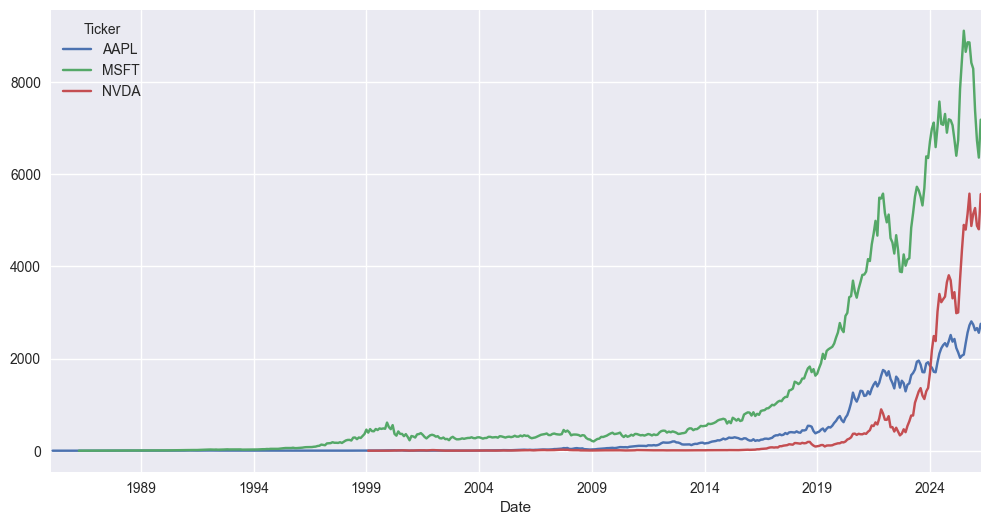

In [36]:
# Plot at least 3 stocks
# Add a brief interpretation

plotting = tickers[0:3]

fig, axs = plt.subplots(figsize=(12, 6))  # this is a tuple (pair) of fig and axs, so we have overall figure info and axes info together
wealth[plotting].plot(ax=axs)  # ax=axs just says to use our defined "axs" instead of making a new one

# can specify parameters like title, labels, line colours, legends, etc.

## 7. Fundamental Indicators – Growth & Quality (≈20 minutes)

Market prices alone are not sufficient for equity analysis.

We complement price performance with **fundamentals**.

Two indicators:
- **Revenue growth** (latest year vs previous year)
- **Operating margin** (operating income / revenue)

Financial statements are accessed using:

    yf.Ticker("AAPL").financials

In [39]:
# TODO:
# For each ticker:
# - retrieve financial statements using yf.Ticker
# - compute revenue growth
# - compute operating margin
# Store results in a DataFrame

records = []

for ticker in tickers:
    fin = yf.Ticker(ticker).financials
    revenue = fin.loc["Total Revenue"]
    operating_income = fin.loc["Operating Income"]
    
    records.append({
        "Ticker": ticker,
        "Revenue Growth": (revenue.iloc[0] - revenue.iloc[1]) / revenue.iloc[1], # .iloc is just indexing with integers instead of dates
        "Operating Margin": operating_income.iloc[0] / revenue.iloc[0]
    })

fundamentals = pd.DataFrame(records).set_index("Ticker")

fundamentals

,Revenue Growth,Operating Margin
Ticker,,
AAPL,0.064255,0.319708
MSFT,0.149322,0.456220
NVDA,0.654735,0.603817
ADBE,0.105278,0.366275
META,0.221670,0.414379
CRM,0.095791,0.214738
ORCL,0.083798,0.314500
NOW,0.208849,0.137370
INTU,0.156340,0.262227


## 8. Screening Table Construction (≈15 minutes)

Professional screeners combine **all signals into one master table**.

Structure:
- each row → one stock
- each column → one screening signal

This table forms the basis for ranking and decision‑making.

In [40]:
# TODO:
# Combine:
# - 12‑month return
# - revenue growth
# - operating margin
# into a single screening table

fundamentals["12M Return"] = trailing_12m.iloc[-1]

fundamentals

,Revenue Growth,Operating Margin,12M Return
Ticker,,,
AAPL,0.064255,0.319708,0.290541
MSFT,0.149322,0.456220,0.065806
NVDA,0.654735,0.603817,0.855560
ADBE,0.105278,0.366275,-0.336951
META,0.221670,0.414379,0.225871
CRM,0.095791,0.214738,-0.300529
ORCL,0.083798,0.314500,0.279178
NOW,0.208849,0.137370,-0.477911
INTU,0.156340,0.262227,-0.348436


## 9. Ranking & Shortlisting Logic (≈15 minutes)

Equity screening is about **narrowing the universe**, not precision.

Rank stocks using:
- revenue growth
- operating margin
- 12‑month performance

Combine ranks into a **composite score**.

There is no single correct answer —
only defensible logic that can be explained.

In [42]:
# TODO:
# Rank each metric
# Compute composite score
# Sort stocks from most to least attractive

fundamentals["Rank_RevGrowth"] = fundamentals["Revenue Growth"].rank(ascending=True)
fundamentals["Rank_OpMargin"] = fundamentals["Operating Margin"].rank(ascending=True)
fundamentals["Rank_12M"] = fundamentals["12M Return"].rank(ascending=True)

# Composite score (equal weight)
fundamentals["Composite Score"] = (
    fundamentals["Rank_RevGrowth"] +
    fundamentals["Rank_OpMargin"] +
    fundamentals["Rank_12M"]
) / 3

# Sort best to worst
fundamentals = fundamentals.sort_values("Composite Score", ascending=False)

fundamentals

,Revenue Growth,Operating Margin,12M Return,Rank_RevGrowth,Rank_OpMargin,Rank_12M,Composite Score
Ticker,,,,,,,
NVDA,0.654735,0.603817,0.855560,10.0,10.0,9.0,9.666667
META,0.221670,0.414379,0.225871,8.0,8.0,6.0,7.333333
AMD,0.343378,0.106643,1.824345,9.0,1.0,10.0,6.666667
MSFT,0.149322,0.456220,0.065806,5.0,9.0,5.0,6.333333
AAPL,0.064255,0.319708,0.290541,1.0,6.0,8.0,5.000000
ADBE,0.105278,0.366275,-0.336951,4.0,7.0,3.0,4.666667
ORCL,0.083798,0.314500,0.279178,2.0,5.0,7.0,4.666667
INTU,0.156340,0.262227,-0.348436,6.0,4.0,2.0,4.000000
CRM,0.095791,0.214738,-0.300529,3.0,3.0,4.0,3.333333


## 10. Stock Selection – Analyst Decision (≈10 minutes)

Your team must now make a **judgement call**.

Select **ONE stock** to recommend for deeper analysis.

Write as if presenting to an **investment committee**.

In [ ]:
### Selected Stock

### Analyst Rationale
- Growth outlook:
- Profitability / quality:
- Market performance:
- Key risks:

## 11. GitHub Collaboration Reflection (≈10 minutes)

Equity research is a **team activity**.

Document:
- Who worked on which sections
- How feature branches and pull requests were used
- Any challenges encountered

- Member A:
- Member B:
- Member C: